Month - The month when the accident occurred

WeekOfMonth - The week of the month when the accident occurred

DayOfWeek - The day of the week when the accident occurred

Make - The manufacturer/brand of the vehicle

AccidentArea - The environment where the accident took place (Urban/Rural)

DayOfWeekClaimed - The day of the week when the claim was officially filed

MonthClaimed - The month when the claim was officially filed

WeekOfMonthClaimed - The week of the month when the claim was officially filed

Sex - The gender of the policyholder

MaritalStatus - The marital status of the policyholder

Age - The numerical age of the policyholder/driver

Fault - Determines who was deemed at fault for the accident (Policy Holder/Third Party)

PolicyType - A concatenation of VehicleCategory and BasePolicy (dropped during preprocessing)

VehicleCategory - The classification of the vehicle

VehiclePrice - The estimated value or price bracket of the vehicle

FraudFound_P - The target variable indicating whether the insurance claim was found to be fraudulent (1 = Fraud, 0 = Not Fraud)

PolicyNumber - A unique row identifier (dropped during preprocessing)

RepNumber - A representative ID code (dropped during preprocessing)

Deductible - The out-of-pocket amount the policyholder must pay before insurance covers repairs

DriverRating - A numerical rating representing the driver's risk profile

Days_Policy_Accident - The number of days between the policy being purchased and the accident occurring

Days_Policy_Claim - The number of days between the policy being purchased and the claim being filed

PastNumberOfClaims - The number of previous claims filed by the policyholder

AgeOfVehicle - The age of the vehicle at the time of the incident

AgeOfPolicyHolder - The age group/bracket of the policyholder

PoliceReportFiled - Indicates whether an official police report was filed

WitnessPresent - Indicates whether an independent witness was present

AgentType - The classification of the insurance agent handling the policy

NumberOfSuppliments - The number of supplemental damage estimates requested after the initial claim

AddressChange_Claim - The timeframe of when the policyholder last changed their address prior to filing the claim

NumberOfCars - The number of vehicles registered to the policyholder's household

Year - The year the incident occurred

BasePolicy - The core type of insurance coverage on the vehicle

Import Libraries

In [1]:
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', None)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv(r'/home/frank/MACHINE LEARNING WSL/InsurAI-Agent/artifacts/fraud_oracle.csv')
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [4]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop(columns=['PolicyNumber', 'RepNumber', 'PolicyType'], inplace=True)

In [8]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport,more than 69000,0,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport,more than 69000,0,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport,more than 69000,0,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sport,20000 to 29000,0,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport,more than 69000,0,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [9]:
df['FraudFound_P'].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [10]:
df['Month'].value_counts()

Month
Jan    1411
May    1367
Mar    1360
Jun    1321
Oct    1305
Dec    1285
Apr    1280
Feb    1266
Jul    1257
Sep    1240
Nov    1201
Aug    1127
Name: count, dtype: int64

In [11]:
df['WeekOfMonth'].value_counts()

WeekOfMonth
3    3640
2    3558
4    3398
1    3187
5    1637
Name: count, dtype: int64

In [12]:
df['Make'].value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

In [13]:
df['AccidentArea'].value_counts()

AccidentArea
Urban    13822
Rural     1598
Name: count, dtype: int64

In [14]:
df['Fault'].value_counts()

Fault
Policy Holder    11230
Third Party       4190
Name: count, dtype: int64

In [15]:
df['VehicleCategory'].value_counts()

VehicleCategory
Sedan      9671
Sport      5358
Utility     391
Name: count, dtype: int64

In [16]:
df['VehiclePrice'].value_counts()

VehiclePrice
20000 to 29000     8079
30000 to 39000     3533
more than 69000    2164
less than 20000    1096
40000 to 59000      461
60000 to 69000       87
Name: count, dtype: int64

In [17]:
df['Days_Policy_Accident'].value_counts()

Days_Policy_Accident
more than 30    15247
none               55
8 to 15            55
15 to 30           49
1 to 7             14
Name: count, dtype: int64

In [18]:
df['Days_Policy_Claim'].value_counts()

Days_Policy_Claim
more than 30    15342
15 to 30           56
8 to 15            21
none                1
Name: count, dtype: int64

In [19]:
df['PastNumberOfClaims'].value_counts()

PastNumberOfClaims
2 to 4         5485
none           4352
1              3573
more than 4    2010
Name: count, dtype: int64

In [20]:
df['AgeOfVehicle'].value_counts()

AgeOfVehicle
7 years        5807
more than 7    3981
6 years        3448
5 years        1357
new             373
4 years         229
3 years         152
2 years          73
Name: count, dtype: int64

In [21]:
df['AgeOfPolicyHolder'].value_counts()

AgeOfPolicyHolder
31 to 35    5593
36 to 40    4043
41 to 50    2828
51 to 65    1392
26 to 30     613
over 65      508
16 to 17     320
21 to 25     108
18 to 20      15
Name: count, dtype: int64

In [22]:
df['PoliceReportFiled'].value_counts()

PoliceReportFiled
No     14992
Yes      428
Name: count, dtype: int64

In [23]:
df['WitnessPresent'].value_counts()

WitnessPresent
No     15333
Yes       87
Name: count, dtype: int64

In [24]:
df['AgentType'].value_counts()

AgentType
External    15179
Internal      241
Name: count, dtype: int64

In [25]:
df['NumberOfSuppliments'].value_counts()

NumberOfSuppliments
none           7047
more than 5    3867
1 to 2         2489
3 to 5         2017
Name: count, dtype: int64

In [26]:
df['AddressChange_Claim'].value_counts()

AddressChange_Claim
no change         14324
4 to 8 years        631
2 to 3 years        291
1 year              170
under 6 months        4
Name: count, dtype: int64

In [27]:
df['NumberOfCars'].value_counts()

NumberOfCars
1 vehicle      14316
2 vehicles       709
3 to 4           372
5 to 8            21
more than 8        2
Name: count, dtype: int64

In [28]:
df['BasePolicy'].value_counts()

BasePolicy
Collision     5962
Liability     5009
All Perils    4449
Name: count, dtype: int64

Numerical Variable Distribution

In [29]:
df_num = df.select_dtypes(include='int').columns

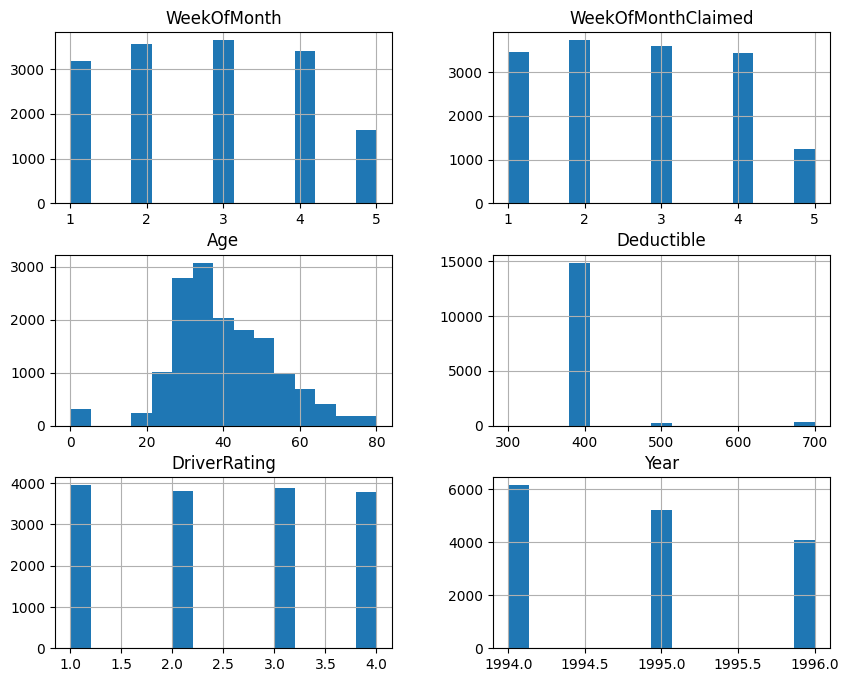

In [30]:
df_num = df._get_numeric_data().drop('FraudFound_P', axis=1)
df_num.hist(bins=15, figsize=(10,8))
plt.show()

Categorical Variable Distribution

In [31]:
df_cat = df.select_dtypes(include='object').columns
df_cat

/tmp/ipykernel_116534/24931894.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df.select_dtypes(include='object').columns


Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'VehicleCategory',
       'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='str')

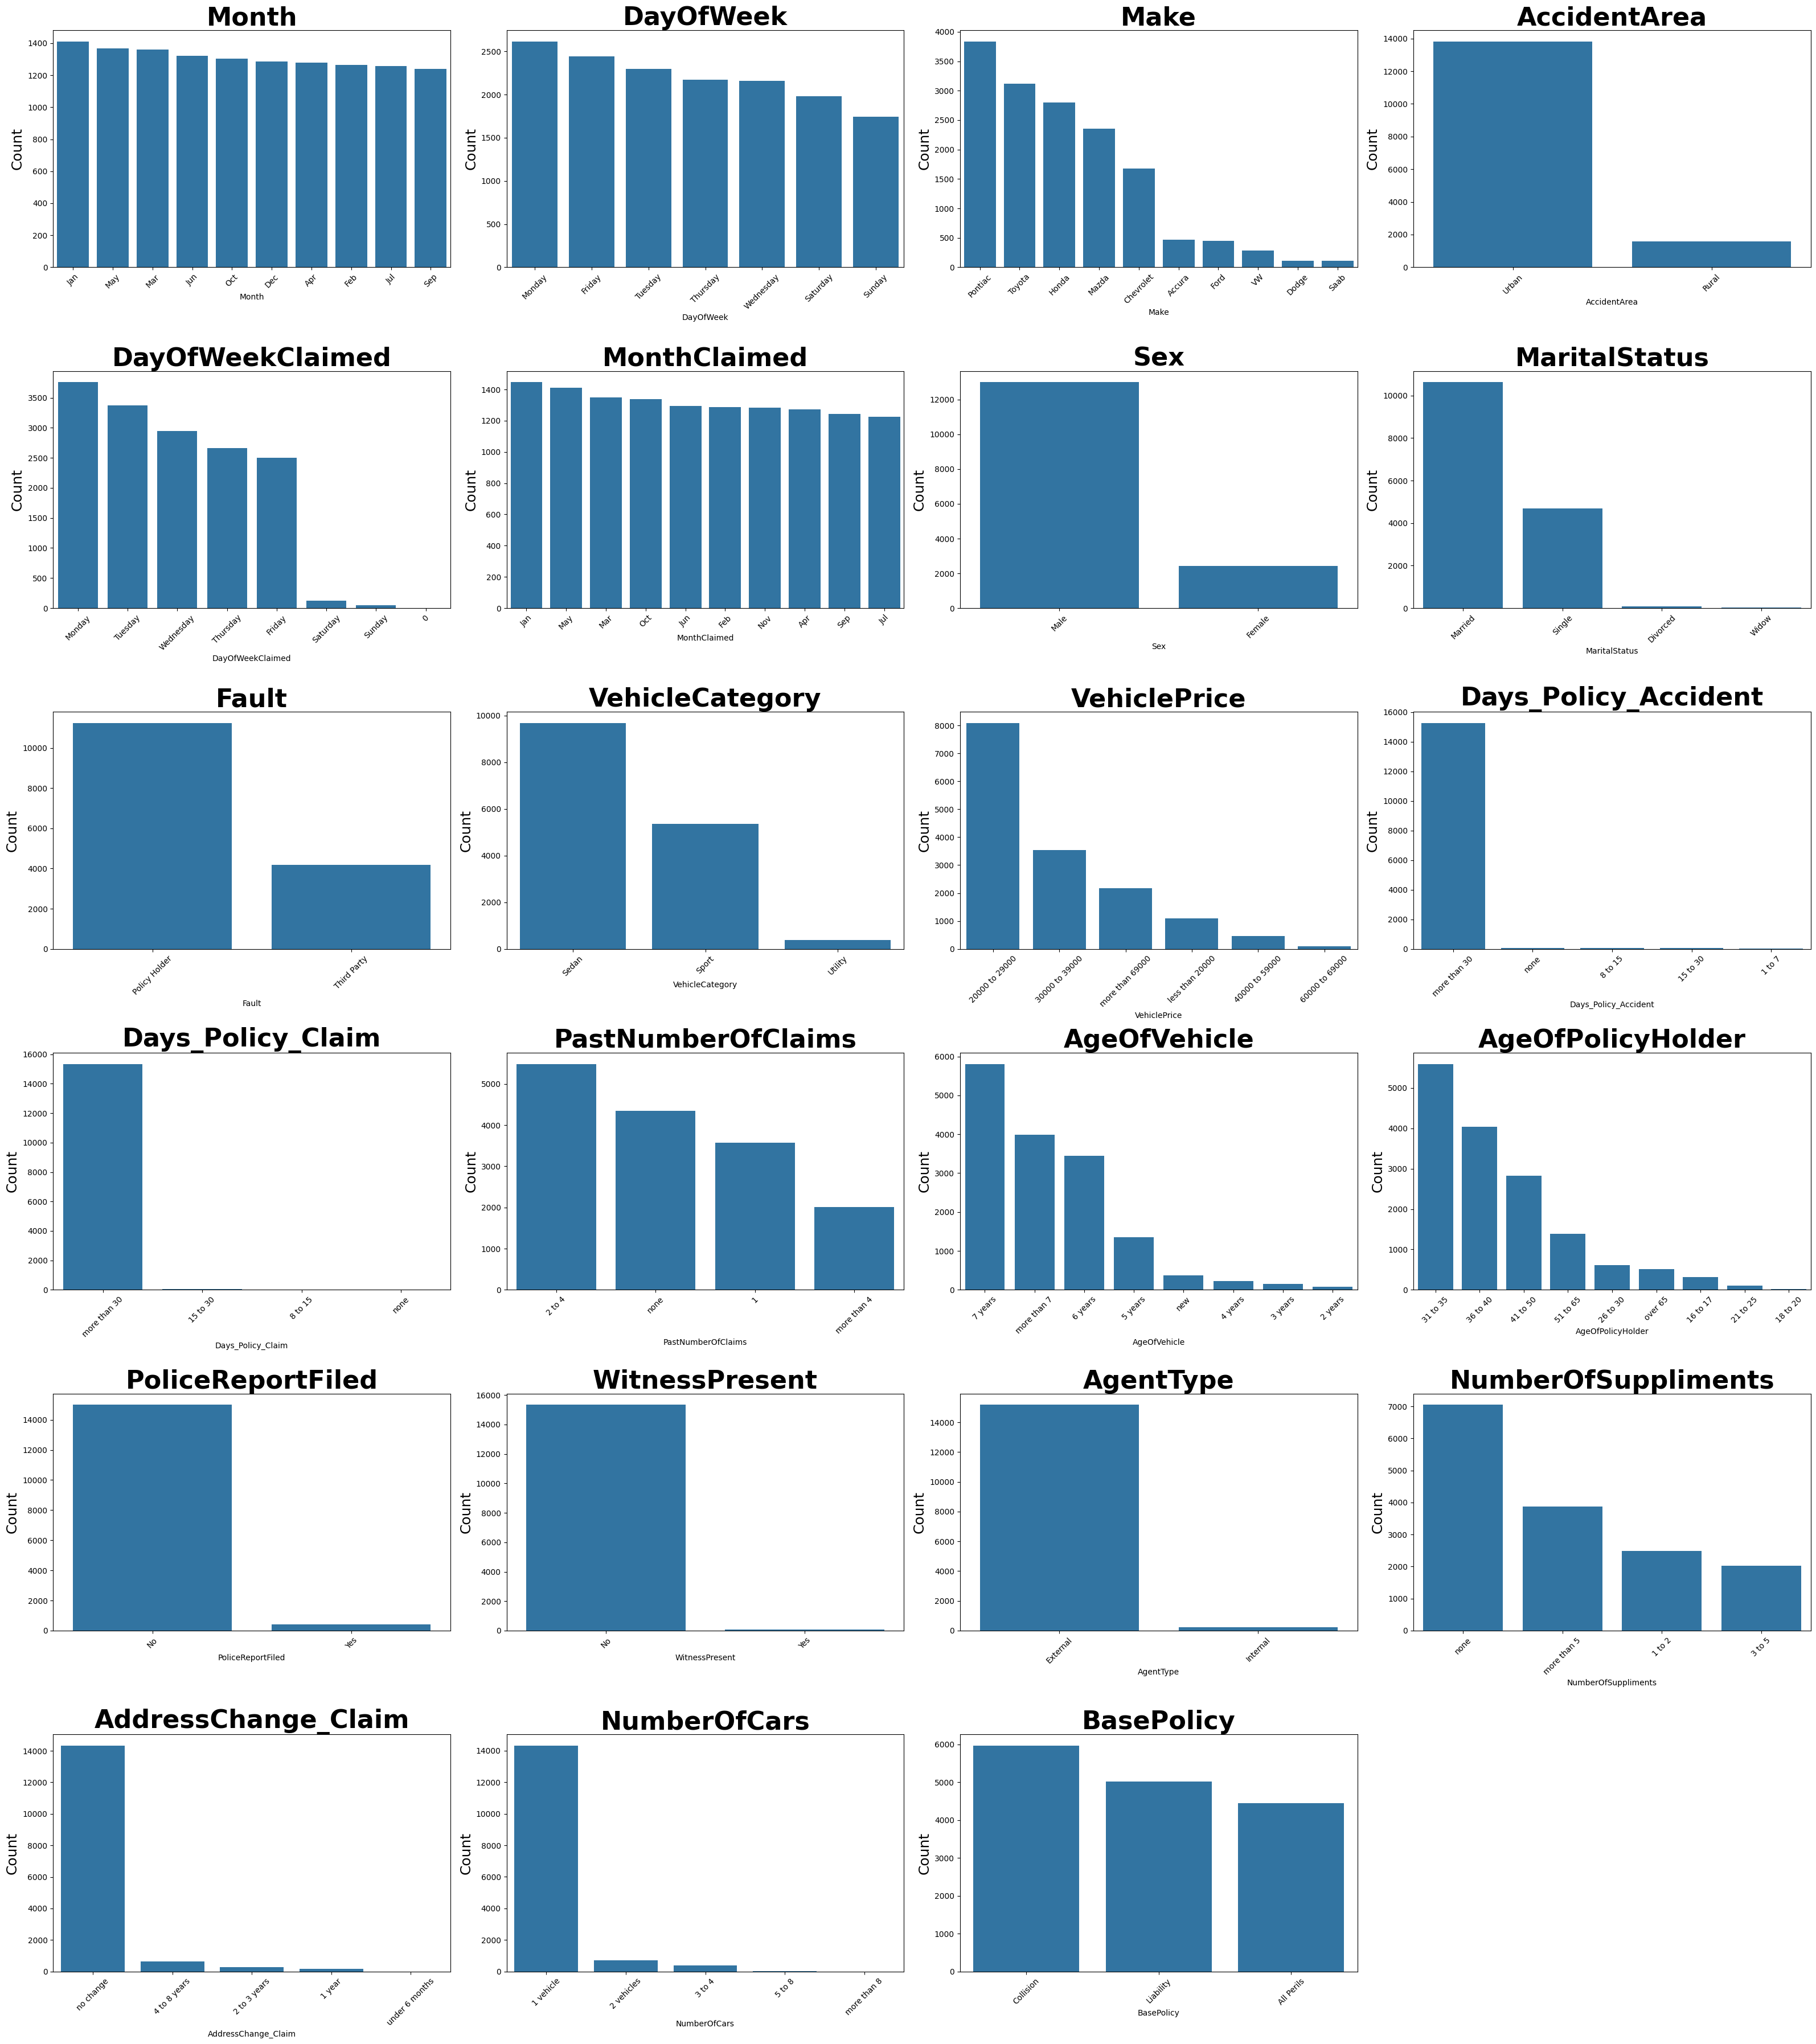

In [32]:
n_cols = 4
n_rows = (len(df_cat) + n_cols - 1) // n_cols

fig = plt.figure(figsize=(8*n_cols, 6*n_rows))

for i, col in enumerate(df_cat):
    ax = fig.add_subplot(n_rows, n_cols, i+1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index[:10], ax=ax)
    ax.set_title(col, fontsize=32, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.set_ylabel('Count', fontsize=18)

plt.tight_layout()
plt.show()

Target Variable Distribution

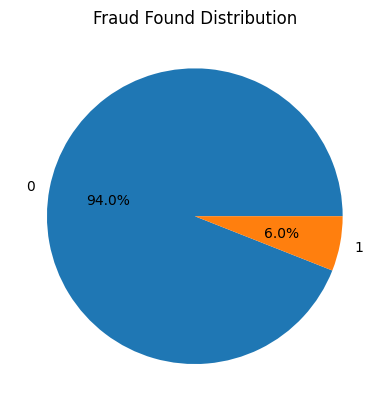

In [33]:
df['FraudFound_P'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Fraud Found Distribution')
plt.show()

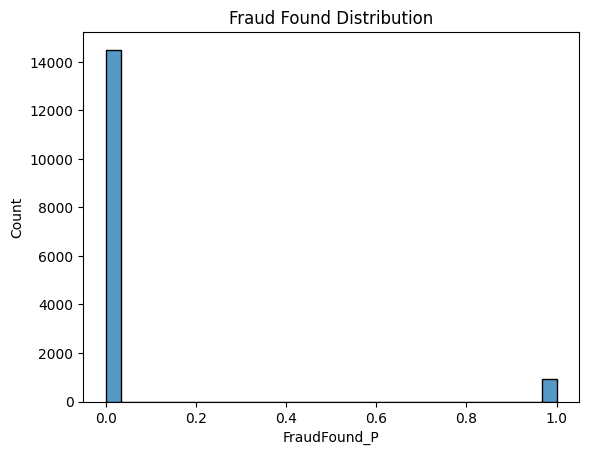

In [34]:
sns.histplot(df['FraudFound_P'], bins=30)
plt.title('Fraud Found Distribution')
plt.show()

Feature Correlation for main dataset

In [35]:
df_num = df._get_numeric_data()

df_corr = df_num.corr()['FraudFound_P'].drop('FraudFound_P')

df_corr

WeekOfMonth          -0.011861
WeekOfMonthClaimed   -0.005761
Age                  -0.029741
Deductible            0.017348
DriverRating          0.007266
Year                 -0.024760
Name: FraudFound_P, dtype: float64

In [36]:
df_num.corr()['FraudFound_P'].drop('FraudFound_P').abs().sort_values(ascending=False)


Age                   0.029741
Year                  0.024760
Deductible            0.017348
WeekOfMonth           0.011861
DriverRating          0.007266
WeekOfMonthClaimed    0.005761
Name: FraudFound_P, dtype: float64

In [37]:
df_num.columns

Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'FraudFound_P',
       'Deductible', 'DriverRating', 'Year'],
      dtype='str')

In [38]:
df_corr = df_num[['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'FraudFound_P',
       'Deductible', 'DriverRating', 'Year']]

df_corr = df_corr.corr()

Feature Correlation Heatmap

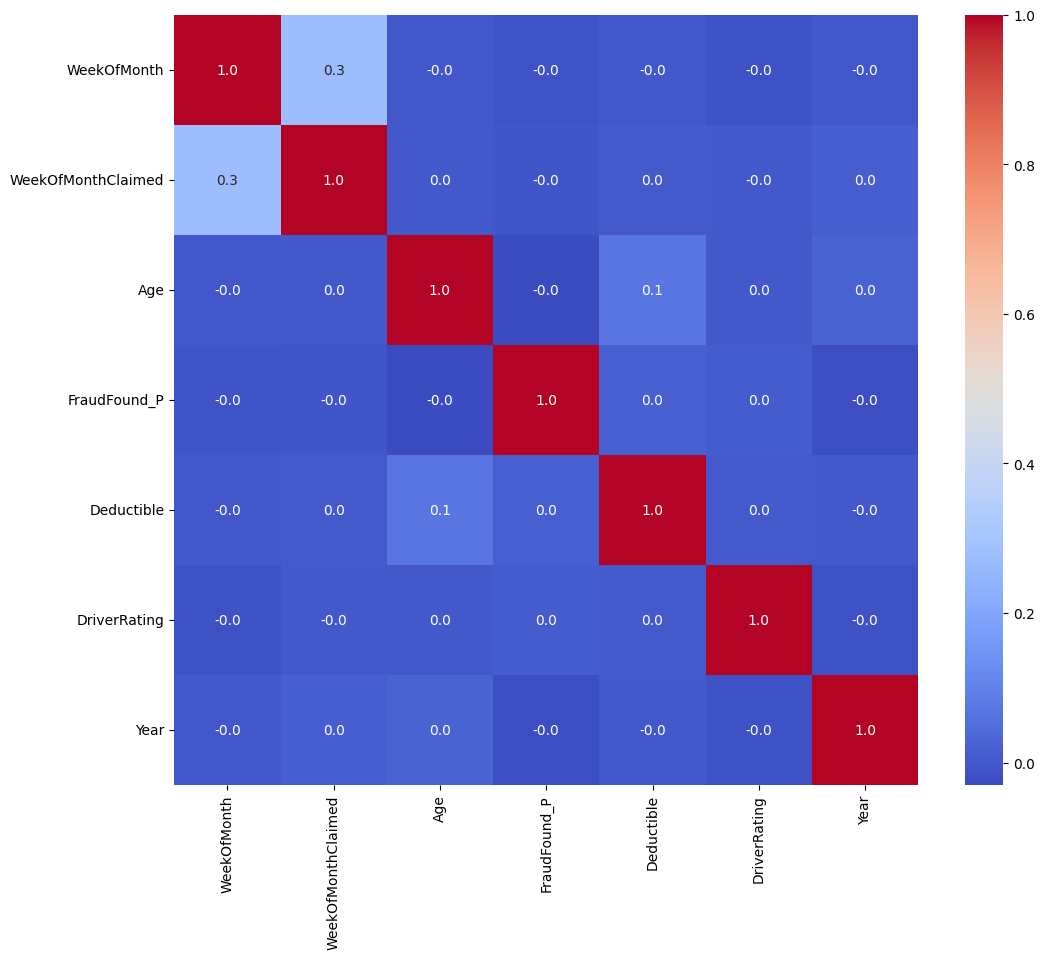

In [39]:
plt.figure(figsize=(12,10))
sns.heatmap(data=df_corr, annot=True, fmt='.1f', cmap='coolwarm')
plt.show()

Data Splitting

In [40]:
train, test = train_test_split(df, test_size=0.3, random_state=42, stratify=df['FraudFound_P'])

In [41]:
train.shape

(10794, 30)

In [42]:
test.shape

(4626, 30)

Data Preprocessing

In [43]:
train.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
12339,Nov,1,Friday,Honda,Urban,Monday,Nov,1,Female,Married,39,Policy Holder,Sedan,20000 to 29000,0,400,2,more than 30,more than 30,none,6 years,36 to 40,No,No,External,more than 5,no change,1 vehicle,1996,Collision
3299,Dec,5,Friday,Chevrolet,Urban,Monday,Jan,1,Male,Married,63,Policy Holder,Sedan,30000 to 39000,0,400,1,more than 30,more than 30,2 to 4,more than 7,51 to 65,No,No,External,none,no change,1 vehicle,1994,Collision
5352,Jan,1,Tuesday,Dodge,Urban,Wednesday,Feb,1,Male,Married,60,Policy Holder,Sedan,20000 to 29000,0,400,4,more than 30,more than 30,1,more than 7,51 to 65,No,No,External,3 to 5,no change,1 vehicle,1994,Collision
13550,Feb,1,Friday,Toyota,Urban,Wednesday,Feb,2,Male,Married,34,Policy Holder,Sedan,20000 to 29000,0,400,4,more than 30,more than 30,2 to 4,7 years,31 to 35,No,No,External,none,no change,1 vehicle,1996,All Perils
4379,Jun,5,Tuesday,Pontiac,Urban,Tuesday,Jun,5,Male,Married,29,Policy Holder,Sedan,20000 to 29000,0,400,2,more than 30,more than 30,1,4 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1994,Collision


In [44]:
train_target = train['FraudFound_P']
train_target.to_csv('train target data.csv', index=False)

train.drop('FraudFound_P', axis=1, inplace=True)
train.to_csv('train data.csv', index=False)

In [45]:
test.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
12974,Oct,2,Tuesday,Pontiac,Urban,Monday,Oct,3,Male,Married,46,Policy Holder,Sport,20000 to 29000,0,400,1,more than 30,more than 30,2 to 4,7 years,41 to 50,No,No,External,3 to 5,no change,1 vehicle,1996,Liability
13756,Mar,2,Monday,Honda,Urban,Monday,Mar,2,Female,Divorced,36,Policy Holder,Sport,20000 to 29000,0,400,3,more than 30,more than 30,2 to 4,7 years,36 to 40,No,No,External,none,no change,1 vehicle,1996,Liability
5420,Apr,4,Sunday,Pontiac,Urban,Tuesday,May,1,Female,Single,48,Policy Holder,Sedan,20000 to 29000,0,400,4,more than 30,more than 30,none,more than 7,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3656,Dec,5,Friday,Accura,Urban,Monday,Jan,2,Male,Married,36,Policy Holder,Utility,more than 69000,0,400,1,more than 30,more than 30,none,more than 7,36 to 40,No,No,External,1 to 2,no change,1 vehicle,1994,All Perils
2664,Oct,3,Saturday,Pontiac,Urban,Monday,Oct,3,Male,Married,39,Policy Holder,Sedan,30000 to 39000,0,400,1,more than 30,more than 30,2 to 4,6 years,36 to 40,No,No,External,3 to 5,no change,1 vehicle,1994,Collision


In [46]:
test_target = test['FraudFound_P']
test_target.to_csv('test target data.csv', index=False)

test.drop('FraudFound_P', axis=1, inplace=True)
test.to_csv('test data.csv', index=False)